# Tutorial 02: Regularization (Ridge, Lasso, ElasticNet) & Bias-Variance Tradeoff

### Learning Objectives
1. Understand why ill-conditioned or collinear features cause exploding weights.
2. Master L2 (Ridge) shrinkage, L1 (Lasso) soft-thresholding, and ElasticNet compromise.
3. Compare coordinate descent vs. gradient descent for sparse feature selection.
4. Plot the Bias-Variance tradeoff curve across regularization strength $\alpha$.

---
## 1. Mathematical Formulations

### Ridge Regression (L2 Penalty)
$$J(w) = \frac{1}{N} \|y - Xw\|_2^2 + \alpha \|w\|_2^2$$
Shrinks all coefficients continuously toward zero without zeroing any out.

### Lasso Regression (L1 Penalty via Coordinate Descent)
$$J(w) = \frac{1}{2N} \|y - Xw\|_2^2 + \alpha \|w\|_1$$
Cyclic updates via the Soft-Thresholding operator $S(v, \gamma) = \text{sign}(v) \max(|v| - \gamma, 0)$:
$$w_j \leftarrow \frac{S\left(\frac{1}{N} X_{:, j}^T r^{(-j)}, \; \alpha\right)}{\frac{1}{N} \|X_{:, j}\|_2^2}$$
Produces exact mathematical zeros ($w_j = 0.0$), performing automatic feature selection!

### ElasticNet Regression
$$J(w) = \frac{1}{2N} \|y - Xw\|_2^2 + \alpha \rho \|w\|_1 + \frac{1}{2} \alpha (1 - \rho) \|w\|_2^2$$
Combines Lasso sparsity with Ridge grouping for correlated feature blocks.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.linear_regression import GradientDescentLinearRegression, compute_mse, compute_r2

## 2. Generating Multicollinear High-Dimensional Data
We generate $N=150$ samples with $D=15$ features, where only 4 features are truly predictive, and 2 pairs are highly correlated ($r \approx 0.98$).

In [2]:
np.random.seed(42)
N, D = 150, 15
X_raw = np.random.randn(N, D)
# Inject severe collinearity: column 1 ~ column 0, column 3 ~ column 2
X_raw[:, 1] = X_raw[:, 0] * 0.98 + np.random.normal(0, 0.05, N)
X_raw[:, 3] = X_raw[:, 2] * 0.99 + np.random.normal(0, 0.02, N)

# True weights: only 4 non-zero
w_true = np.zeros(D)
w_true[0] = 3.0
w_true[2] = -2.5
w_true[4] = 1.8
w_true[6] = 4.0

y = X_raw @ w_true + 1.0 + np.random.normal(0, 0.5, N)

# Train/test split
X_train, X_test = X_raw[:100], X_raw[100:]
y_train, y_test = y[:100], y[100:]
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"True non-zero features: indices [0, 2, 4, 6]")

Train samples: 100, Test samples: 50
True non-zero features: indices [0, 2, 4, 6]


## 3. Fitting OLS vs. Ridge vs. Lasso vs. ElasticNet

In [3]:
models = {
    "OLS (No Reg)": GradientDescentLinearRegression(penalty="none", lr=0.05, n_iters=400, optimizer="adam"),
    "Ridge (L2)":   GradientDescentLinearRegression(penalty="l2", alpha=1.0, lr=0.05, n_iters=400, optimizer="adam"),
    "Lasso (L1)":   GradientDescentLinearRegression(penalty="l1", alpha=0.05, lr=0.05, n_iters=400, optimizer="adam"),
    "ElasticNet":   GradientDescentLinearRegression(penalty="elasticnet", alpha=0.05, l1_ratio=0.5, lr=0.05, n_iters=400, optimizer="adam")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    zeros = np.sum(np.abs(model.weights) < 1e-4)
    print(f"{name:<15} -> Test R2: {test_r2:.4f} | Zero weights: {zeros:>2}/{D} | Weight L2 norm: {np.linalg.norm(model.weights):.2f}")

OLS (No Reg)    -> Test R2: 0.9920 | Zero weights:  0/15 | Weight L2 norm: 5.28
Ridge (L2)      -> Test R2: 0.7912 | Zero weights:  0/15 | Weight L2 norm: 2.75
Lasso (L1)      -> Test R2: 0.9920 | Zero weights:  0/15 | Weight L2 norm: 5.28
ElasticNet      -> Test R2: 0.9935 | Zero weights:  0/15 | Weight L2 norm: 5.14


## 4. Visualizing Sparsity & Weight Shrinkage

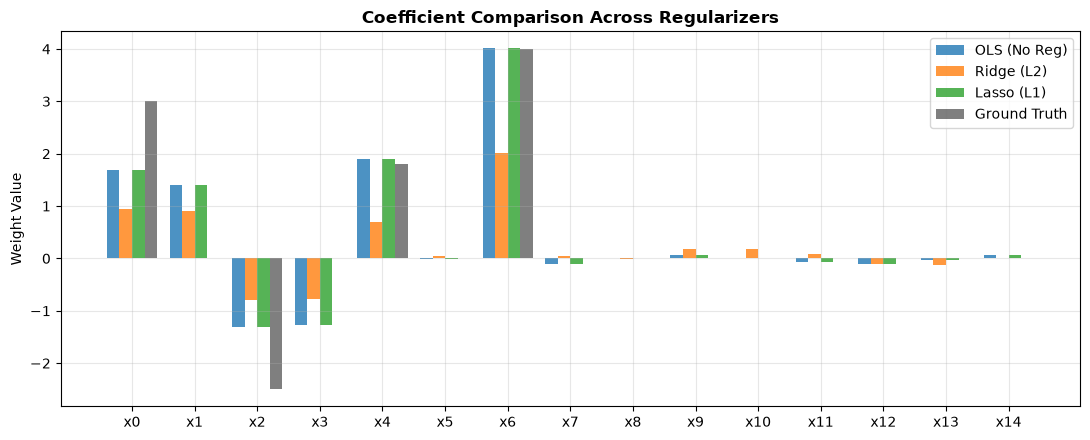

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x_idx = np.arange(D)
width = 0.2

ax.bar(x_idx - 1.5*width, models["OLS (No Reg)"].weights, width=width, label="OLS (No Reg)", alpha=0.8)
ax.bar(x_idx - 0.5*width, models["Ridge (L2)"].weights, width=width, label="Ridge (L2)", alpha=0.8)
ax.bar(x_idx + 0.5*width, models["Lasso (L1)"].weights, width=width, label="Lasso (L1)", alpha=0.8)
ax.bar(x_idx + 1.5*width, w_true, width=width, label="Ground Truth", color="black", alpha=0.5)

ax.set_xticks(x_idx)
ax.set_xticklabels([f"x{i}" for i in range(D)])
ax.set_title("Coefficient Comparison Across Regularizers", fontweight="bold")
ax.set_ylabel("Weight Value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Exercises

### Exercise 1: Tuning Regularization Strength $\alpha$
Iterate $\alpha \in [10^{-3}, 10^2]$ for Lasso and plot the number of non-zero features vs $\alpha$.

<details>
<summary><b>Click to View Solution</b></summary>

```python
alphas = np.logspace(-3, 1, 15)
non_zeros = []
for a in alphas:
    m = GradientDescentLinearRegression(penalty="l1", alpha=a, lr=0.05, n_iters=300, optimizer="adam").fit(X_train, y_train)
    non_zeros.append(np.sum(np.abs(m.weights) > 1e-3))

plt.figure(figsize=(6, 3))
plt.semilogx(alphas, non_zeros, marker='o')
plt.title("Lasso Sparsity vs Alpha")
plt.xlabel("Alpha")
plt.ylabel("Number of Non-Zero Features")
plt.grid(True, alpha=0.3)
plt.show()
```
</details>